# Double Descent: The ISLR Natural Spline Example

**Math 280: Mathematical and Statistical Foundations of Data Science**  
Reference: ISLR Section 10.8 (James, Witten, Hastie, Tibshirani)

---

This notebook reproduces the double descent example from ISLR Section 10.8. It is a companion to the Gaussian linear model notebook, but the setup here is more visual — you can literally *see* the fitted curve going wild at the interpolation threshold and then calming down as we add more basis functions.

### The Setup

We simulate $n = 20$ observations from:
$$Y = \sin(X) + \varepsilon, \qquad X \sim U[-5,5], \quad \varepsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.3$$

We fit a **natural cubic spline** with $d$ degrees of freedom — equivalently, a least-squares regression of $Y$ onto $d$ spline basis functions. As $d$ increases from 1 to 80:

- **$d < n = 20$**: underparameterized, unique least-squares solution, does not interpolate
- **$d = n = 20$**: exactly at the interpolation threshold, unique solution that fits every training point exactly — but wildly
- **$d > n = 20$**: overparameterized, infinitely many interpolating solutions, pseudoinverse selects the **minimum-norm** one

### A note on numerical behavior near $d = n$

When many knots are placed near $n = 20$ data points, the basis matrix becomes nearly singular and the pseudoinverse amplifies noise dramatically. This produces the spike in test error near the threshold — which is real and expected, not a numerical artifact. ISLR's Figure 10.20 shows the same spike (they cap the y-axis at 2.0 to keep the plot readable). We do the same.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import pinv, matrix_rank
from scipy.interpolate import BSpline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Ready.')

Ready.


## 1. Natural Spline Basis

A natural cubic spline with $d$ degrees of freedom is built from $d$ basis functions. We use a B-spline basis with $d - 4$ interior knots placed at quantiles of the training data. Fitting is done via the pseudoinverse, which automatically gives the minimum-norm solution when $d > n$.

**Key property to verify:** when $d = n = 20$, the training MSE should be exactly zero (interpolation). When $d > n$, training MSE stays zero but the norm $\|\hat{\beta}\|^2$ should decrease as $d$ grows.

In [2]:
def ns_basis(x_train, x_eval, d, x_min=-5, x_max=5):
    """
    Natural cubic spline basis with d degrees of freedom.

    Uses a B-spline basis of degree 3 with d-4 interior knots
    placed at quantiles of x_train. The same knot locations are
    used for both x_train and x_eval to avoid information leakage.

    When d <= 4, falls back to a polynomial basis.

    Parameters
    ----------
    x_train : 1-d array, training x values (used to place knots)
    x_eval  : 1-d array, evaluation x values
    d       : int, degrees of freedom

    Returns
    -------
    B_train : array (len(x_train), actual_d)
    B_eval  : array (len(x_eval),  actual_d)
    """
    degree = 3
    n_interior = max(d - (degree + 1), 0)

    # For very small d, use a simple polynomial basis
    if n_interior == 0:
        B_tr   = np.column_stack([x_train**k for k in range(d)])
        B_eval = np.column_stack([x_eval**k  for k in range(d)])
        return B_tr, B_eval

    # Place interior knots at quantiles of training data
    interior_knots = np.quantile(
        x_train, np.linspace(0, 1, n_interior + 2)[1:-1]
    )
    # Full knot sequence with boundary knots (degree+1 copies at each end)
    t = np.concatenate([
        [x_min] * (degree + 1),
        interior_knots,
        [x_max] * (degree + 1)
    ])
    n_basis = len(t) - degree - 1

    def make_col(x, j):
        c = np.zeros(n_basis); c[j] = 1.0
        return BSpline(t, c, degree)(np.clip(x, x_min, x_max))

    B_tr   = np.column_stack([make_col(x_train, j) for j in range(n_basis)])
    B_eval = np.column_stack([make_col(x_eval,  j) for j in range(n_basis)])
    return B_tr, B_eval


print('ns_basis() defined.')

ns_basis() defined.


## 2. Generate the Data

In [3]:
# Parameters matching ISLR Section 10.8 exactly
n     = 20
sigma = 0.3
x_min, x_max = -5, 5

# Training data
X_train = np.random.uniform(x_min, x_max, n)
y_train = np.sin(X_train) + np.random.normal(0, sigma, n)

# Fine grid for plotting the true function and fitted curves
X_grid = np.linspace(x_min, x_max, 500)
y_true = np.sin(X_grid)

# Signal-to-noise ratio (ISLR reports ~5.9)
snr = np.var(np.sin(np.linspace(x_min, x_max, 10000))) / sigma**2

print(f'n     = {n}  (interpolation threshold at d = n = {n})')
print(f'sigma = {sigma}')
print(f'SNR   = {snr:.2f}  (ISLR reports ~5.9)')

n     = 20  (interpolation threshold at d = n = 20)
sigma = 0.3
SNR   = 5.86  (ISLR reports ~5.9)


## 3. Sweep: Train and Test Error vs. $d$

We average test error over many independent test sets to get a stable curve.

In [18]:
d_values  = np.arange(1, 121)
n_test_reps = 300   # average over this many independent test sets
n_test_obs  = 500   # test observations per replicate

train_mse = np.zeros(len(d_values))
test_mse  = np.zeros(len(d_values))
beta_norm = np.zeros(len(d_values))

# Store fitted curves at four key d values for visualization
d_showcase   = [8, 20, 42, 80]
fitted_curves = {}

for idx, d in enumerate(d_values):
    B_tr, B_grid = ns_basis(X_train, X_grid, d, x_min, x_max)
    bh = pinv(B_tr) @ y_train

    train_mse[idx] = np.mean((y_train - B_tr @ bh)**2)
    beta_norm[idx] = np.sum(bh**2)

    # Average test MSE over many test sets for a stable curve
    te_reps = []
    for rep in range(n_test_reps):
        rng     = np.random.default_rng(seed=200 + idx * 100 + rep)
        X_tobs  = rng.uniform(x_min, x_max, n_test_obs)
        y_tobs  = np.sin(X_tobs) + rng.normal(0, sigma, n_test_obs)
        _, B_tob = ns_basis(X_train, X_tobs, d, x_min, x_max)
        te_reps.append(np.mean((y_tobs - B_tob @ bh)**2))
    test_mse[idx] = np.mean(te_reps)

    # Save fitted curve for visualization
    if d in d_showcase:
        fitted_curves[d] = {
            'y_hat'    : B_grid @ bh,
            'norm'     : np.sum(bh**2),
            'train_mse': train_mse[idx],
            'test_mse' : test_mse[idx],
        }

    # Progress indicator
    if d % 10 == 0 or d == 1:
        print(f'd={d:3d} / 120   train_MSE={train_mse[idx]:.5f}   '
              f'test_MSE={min(test_mse[idx], 999):.4f}   '
              f'||beta||^2={beta_norm[idx]:.2e}')

print('\nSweep complete.')
print(f'Training MSE at d = {n}: {train_mse[n-1]:.8f}   (should be ~0)')
print(f'||beta||^2 at d = {n}:  {beta_norm[n-1]:.3e}')
print(f'||beta||^2 at d = 80:   {beta_norm[79]:.3e}   (should be much smaller)')

d=  1 / 120   train_MSE=0.53138   test_MSE=0.6229   ||beta||^2=8.04e-03
d= 10 / 120   train_MSE=0.04125   test_MSE=0.1375   ||beta||^2=1.10e+01
d= 20 / 120   train_MSE=0.00000   test_MSE=999.0000   ||beta||^2=1.04e+09
d= 30 / 120   train_MSE=0.00000   test_MSE=999.0000   ||beta||^2=1.74e+05
d= 40 / 120   train_MSE=0.00000   test_MSE=999.0000   ||beta||^2=1.01e+05
d= 50 / 120   train_MSE=0.00000   test_MSE=12.0004   ||beta||^2=5.46e+03
d= 60 / 120   train_MSE=0.00000   test_MSE=0.2926   ||beta||^2=1.97e+01
d= 70 / 120   train_MSE=0.00000   test_MSE=1.4996   ||beta||^2=3.18e+02
d= 80 / 120   train_MSE=0.00000   test_MSE=0.3476   ||beta||^2=2.18e+01
d= 90 / 120   train_MSE=0.00000   test_MSE=0.3807   ||beta||^2=2.05e+01
d=100 / 120   train_MSE=0.00000   test_MSE=0.3955   ||beta||^2=2.12e+01
d=110 / 120   train_MSE=0.00000   test_MSE=0.4125   ||beta||^2=2.08e+01
d=120 / 120   train_MSE=0.00000   test_MSE=0.4263   ||beta||^2=2.08e+01

Sweep complete.
Training MSE at d = 20: 0.00000000   (sh

## 4. The Double Descent Curve

Reproduces ISLR Figure 10.20. The y-axis is capped at 2.0 (as in ISLR) because the test error spikes to very large values near $d = n = 20$.

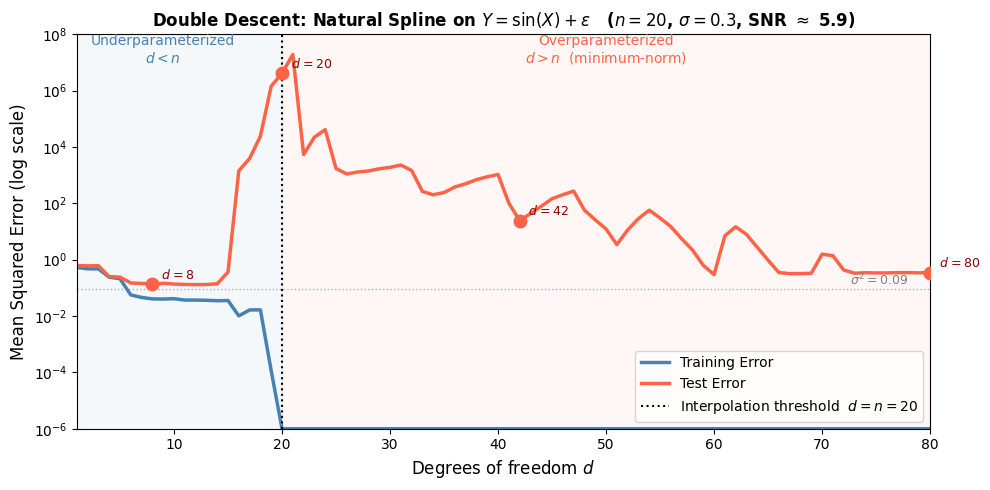

Saved: islr_double_descent_curve.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.semilogy(d_values, train_mse + 1e-6,          # small offset avoids log(0)
            color='steelblue', lw=2.5, label='Training Error')
ax.semilogy(d_values, test_mse,
            color='tomato', lw=2.5, label='Test Error')

ax.axvline(n, color='black', lw=1.5, ls=':',
           label=f'Interpolation threshold  $d = n = {n}$')
ax.axhline(sigma**2, color='gray', lw=1, ls=':', alpha=0.6)
ax.text(78, sigma**2 * 1.4,
        f'$\\sigma^2 = {sigma**2}$', ha='right', fontsize=9, color='gray')

# Shaded regimes — use axis limits for y extent
y_lo, y_hi = 1e-6, 1e8
ax.fill_betweenx([y_lo, y_hi], 0, n,  alpha=0.05, color='steelblue')
ax.fill_betweenx([y_lo, y_hi], n, 80, alpha=0.05, color='tomato')
ax.text(n * 0.45, y_hi * 0.1,
        'Underparameterized\n$d < n$',
        ha='center', fontsize=10, color='steelblue')
ax.text(50, y_hi * 0.1,
        'Overparameterized\n$d > n$  (minimum-norm)',
        ha='center', fontsize=10, color='tomato')

# Mark the four showcase points
for d in d_showcase:
    te = test_mse[d-1]
    ax.plot(d, te, 'o', color='tomato', ms=9, zorder=5)
    ax.annotate(f' $d={d}$', xy=(d, te), fontsize=9,
                color='darkred', xytext=(4, 4),
                textcoords='offset points')

ax.set_xlabel('Degrees of freedom $d$', fontsize=12)
ax.set_ylabel('Mean Squared Error (log scale)', fontsize=12)
ax.set_title(
    f'Double Descent: Natural Spline on $Y = \\sin(X) + \\varepsilon$   '
    f'($n={n}$, $\\sigma={sigma}$, SNR $\\approx$ {snr:.1f})',
    fontsize=12, fontweight='bold'
)
ax.set_xlim(1, 80)
ax.set_ylim(y_lo, y_hi)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('islr_double_descent_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: islr_double_descent_curve.png')

## 5. The Four Fitted Curves

Reproduces ISLR Figure 10.21. Each panel shows the fitted spline at one value of $d$.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    f'Fitted Natural Splines at Four Values of $d$   ($n={n}$, $\\sigma={sigma}$)',
    fontsize=13, fontweight='bold'
)

annotations = {
    8:  ('steelblue',  '#f0f8ff', 'Underfitting: smooth\nbut misses the signal'),
    20: ('tomato',     '#fff0f0', 'At threshold: unique\ninterpolant — wild!'),
    42: ('darkgreen',  '#f0fff0', 'Minimum-norm: interpolates\nbut much smoother'),
    80: ('darkgreen',  '#f0fff0', 'Even more parameters:\nbarely different from $d=42$'),
}

for ax, d in zip(axes.flat, d_showcase):
    curve = fitted_curves[d]
    color, bg, note = annotations[d]

    ax.set_facecolor(bg)
    ax.plot(X_grid, y_true, color='black', lw=2,
            label='True $f(x)=\\sin(x)$', zorder=3)
    ax.plot(X_grid, curve['y_hat'], color=color, lw=2,
            label=f'$\\hat{{f}}_{{{d}}}(x)$', zorder=2)
    ax.scatter(X_train, y_train, color='steelblue', s=45,
               zorder=4, label='Training data', alpha=0.85)

    regime = ('underparameterized' if d < n else
              'interpolation threshold' if d == n else
              'overparameterized (min-norm)')

    norm_str = (f'{curve["norm"]:.1f}' if curve['norm'] < 1e6
                else f'{curve["norm"]:.2e}')

    ax.set_title(
        f'$d = {d}$  [{regime}]\n'
        f'Train MSE = {curve["train_mse"]:.4f}   '
        f'$\\|\\hat{{\\beta}}\\|^2 = {norm_str}$',
        fontsize=10
    )
    ax.text(0, 3.3, note, ha='center', fontsize=9, color=color,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-4.2, 4.2)
    ax.set_xlabel('$x$', fontsize=10)
    ax.set_ylabel('$y$', fontsize=10)
    ax.legend(fontsize=8, loc='lower right')
    ax.axhline(0, color='gray', lw=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('islr_double_descent_fits.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: islr_double_descent_fits.png')

## 6. The Coefficient Norm: Why the Overparameterized Fits Are Smoother

The key insight from ISLR Section 10.8: at $d = 20$ there is exactly **one** way to interpolate, and it requires enormous coefficients. At $d > 20$ there are infinitely many interpolating solutions; the minimum-norm one has much smaller coefficients and is therefore smoother.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Minimum-Norm Interpolation: Why Overparameterization Helps',
             fontsize=12, fontweight='bold')

# Left: coefficient norm vs d
ax = axes[0]
norm_cap = np.percentile(beta_norm[beta_norm < 1e10], 95) * 1.5
ax.plot(d_values, np.minimum(beta_norm, norm_cap),
        color='purple', lw=2)
ax.axvline(n, color='black', lw=1.5, ls=':',
           label=f'$d = n = {n}$')
ax.fill_betweenx([0, norm_cap], 0, n,  alpha=0.05, color='steelblue')
ax.fill_betweenx([0, norm_cap], n, 80, alpha=0.05, color='tomato')
ax.set_xlabel('Degrees of freedom $d$', fontsize=11)
ax.set_ylabel('$\\|\\hat{\\beta}\\|^2$  (coefficient norm)', fontsize=11)
ax.set_title(
    'Norm peaks at $d = n$ (unique, wild solution)\n'
    'then decreases — minimum-norm picks simpler solution',
    fontsize=10
)
ax.set_ylim(0, norm_cap)
ax.legend(fontsize=10)

# Right: annotated values at showcase d
ax = axes[1]
ax.axis('off')
headers = ['$d$', 'Train MSE', '$\\|\\hat{\\beta}\\|^2$', 'Interpretation']
rows = [
    [8,  train_mse[7],  beta_norm[7],  'Underfitting, small norm'],
    [20, train_mse[19], beta_norm[19], 'Interpolates, norm HUGE'],
    [42, train_mse[41], beta_norm[41], 'Interpolates, norm smaller'],
    [80, train_mse[79], beta_norm[79], 'Interpolates, norm smallest'],
]

table_data = []
for d, tr, no, interp in rows:
    no_str = f'{no:.1f}' if no < 1e6 else f'{no:.2e}'
    table_data.append([str(d), f'{tr:.5f}', no_str, interp])

tbl = ax.table(
    cellText=table_data,
    colLabels=['d', 'Train MSE', '||beta||^2', 'Interpretation'],
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.0)
# Highlight the threshold row
for col in range(4):
    tbl[(2, col)].set_facecolor('#ffe0e0')
ax.set_title('Key values', fontsize=11, pad=20)

plt.tight_layout()
plt.savefig('islr_double_descent_norm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: islr_double_descent_norm.png')

## 7. Numerical Summary

In [ ]:
check_d = [3, 5, 8, 10, 15, 18, 19, 20, 21, 25, 30, 42, 60, 80]

print(f'Signal-to-noise ratio: {snr:.2f}  (ISLR reports ~5.9)')
print(f'Interpolation threshold: d = n = {n}')
print()
print(f"{'d':>5} {'Train MSE':>12} {'Test MSE':>14} {'||beta||^2':>14}")
print('-' * 50)
for d in check_d:
    tr = train_mse[d-1]
    te = test_mse[d-1]
    no = beta_norm[d-1]
    te_str = f'{te:.4f}'    if te < 1e4 else f'{te:.3e}'
    no_str = f'{no:.4f}'   if no < 1e4 else f'{no:.3e}'
    flag   = '  <- threshold' if d == n else ''
    print(f'{d:>5} {tr:>12.4f} {te_str:>14} {no_str:>14}{flag}')

## 8. Exploration: What Happens with Different Noise Levels?

ISLR notes that double descent works well here because the signal-to-noise ratio is high (~5.9). What happens when we increase the noise?

In [ ]:
def run_experiment(n=20, sigma=0.3, seed=42, d_max=80,
                   n_test_reps=50, n_test_obs=300, label=''):
    """Run the full ISLR spline double descent experiment."""
    np.random.seed(seed)
    X_tr = np.random.uniform(x_min, x_max, n)
    y_tr = np.sin(X_tr) + np.random.normal(0, sigma, n)
    snr  = np.var(np.sin(np.linspace(x_min, x_max, 5000))) / sigma**2

    ds      = np.arange(1, d_max + 1)
    tr_mse  = np.zeros(len(ds))
    te_mse  = np.zeros(len(ds))

    for idx, d in enumerate(ds):
        B_tr, _ = ns_basis(X_tr, X_tr, d, x_min, x_max)
        bh = pinv(B_tr) @ y_tr
        tr_mse[idx] = np.mean((y_tr - B_tr @ bh)**2)
        reps = []
        for rep in range(n_test_reps):
            rng   = np.random.default_rng(seed=500 + idx*100 + rep)
            X_tob = rng.uniform(x_min, x_max, n_test_obs)
            y_tob = np.sin(X_tob) + rng.normal(0, sigma, n_test_obs)
            _, B_tob = ns_basis(X_tr, X_tob, d, x_min, x_max)
            reps.append(np.mean((y_tob - B_tob @ bh)**2))
        te_mse[idx] = np.mean(reps)

    cap = 2.5
    fig, ax = plt.subplots(figsize=(9, 4))
    title = label if label else f'n={n}, sigma={sigma:.1f}, SNR={snr:.1f}'
    ax.set_title(title, fontsize=11)
    ax.plot(ds, tr_mse,                     color='steelblue', lw=2, label='Training Error')
    ax.plot(ds, np.minimum(te_mse, cap),    color='tomato',    lw=2, label=f'Test Error (capped at {cap})')
    ax.axvline(n, color='black', lw=1.5, ls=':', label=f'$d=n={n}$')
    ax.axhline(sigma**2, color='gray', lw=1, ls=':', alpha=0.5)
    ax.set_xlabel('Degrees of freedom $d$', fontsize=11)
    ax.set_ylabel('MSE', fontsize=11)
    ax.set_ylim(0, cap)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

# Baseline
run_experiment(n=20, sigma=0.3,
    label=f'Baseline (ISLR): sigma=0.3, SNR={np.var(np.sin(np.linspace(-5,5,5000)))/0.3**2:.1f} — strong second descent')

In [ ]:
# Higher noise: second descent is weaker
run_experiment(n=20, sigma=1.0,
    label=f'Higher noise: sigma=1.0, SNR={np.var(np.sin(np.linspace(-5,5,5000)))/1.0**2:.1f} — second descent weaker')

In [ ]:
# More data: threshold shifts right to d=40
run_experiment(n=40, sigma=0.3,
    label='More data: n=40 — interpolation threshold shifts right to d=40')

## 9. Key Takeaways (ISLR Section 10.8)

1. **Why does $d = n$ give such a wild fit?** There is exactly *one* function in our model class that interpolates $n = 20$ points with $d = 20$ basis functions. That unique solution requires enormous coefficients and wiggles wildly between data points.

2. **Why do $d = 42$ and $d = 80$ give smooth fits despite also interpolating?** There are infinitely many interpolating solutions. The pseudoinverse (minimum-norm) selects the one with the smallest $\|\hat{\beta}\|^2$. In a large solution space, the minimum-norm element is less constrained and can be much smoother.

3. **The three conditions (from lecture notes) in this spline setting:**
   - *True model is simple*: $\sin(x)$ is smooth — small norm in the function space ✓
   - *Function class rich enough*: natural splines can approximate $\sin(x)$ well ✓
   - *Algorithm finds minimum-norm*: pseudoinverse selects smallest $\|\hat{\beta}\|^2$ ✓

4. **Signal-to-noise ratio matters.** The second descent works here because SNR $\approx 5.9$ is high. With more noise, interpolating the data means fitting more noise, and the second descent is weaker or absent.

5. **Double descent does not contradict bias-variance.** The x-axis ($d$) does not properly measure "flexibility" in the overparameterized regime. The minimum-norm spline with $d = 42$ has *lower variance* than the one at $d = 20$, even though it has more degrees of freedom. The tradeoff still holds — we just need to measure complexity correctly.